In [1]:
#import stuff
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from datetime import datetime
import itertools

from scipy.optimize import curve_fit, differential_evolution
#import numpy.ma as ma

from curve_fitting import *
from goodness_fit_measures import *

plt.rcParams['figure.facecolor'] = 'white'
save_dir = "./plots"

In [2]:
#read tech data
df = pd.read_csv('data/HATCH_v1.5_Clean.csv', keep_default_na=False, index_col = 0,
                       na_values=['-1.#IND', '1.#QNAN', '1.#IND', '-1.#QNAN', '#N/A N/A', '#N/A', 'N/A', 'n/a', 
                                  '<NA>', '#NA', 'NULL', 'null', 'NaN', '-NaN', 'nan', '-nan', 'None', '',0])

#convert country code NA to Namibia and all others to missing value
#convert 0 to missing value
all_years = pd.to_numeric(df.columns, errors='coerce').dropna().astype(int)
years_dict = {str(i): i for i in all_years}
df = df.rename(columns=years_dict)

13


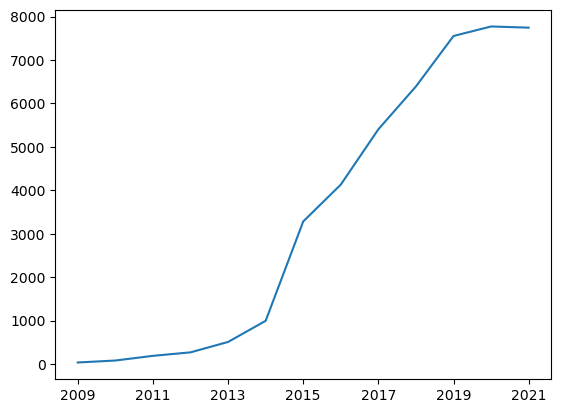

In [3]:
tech_name = 'Offshore Wind Energy'
metric = 'Installed electricity capacity'
region = 'DEU'
slice = df[(df['Technology Name'] == tech_name) &
            (df['Metric'] == metric) &
            (df['Region'] == region)][all_years].transpose().dropna()

slice = df.loc['Offshore Wind Energy_Installed electricity capacity_DE'][all_years].transpose().dropna()

print(len(slice))
slice.plot()

years = slice.index.to_numpy(dtype='float')
values = slice.to_numpy(dtype='float')

## Test differential evolution

In [4]:
def compute_sum_of_squared_error(params, func, x_data, y_data):
    return np.sum((y_data - func(x_data, *params)) ** 2)

def compute_sum_of_abs_error(params, func, x_data, y_data):
    return np.sum(np.abs(y_data - func(x_data, *params)))

def compute_sum_of_relative_error(params, func, x_data, y_data):
    return np.sum(np.abs(y_data - func(x_data, *params))/y_data)

# differential_evolution optimization
def generate_initial_parameters(param_bounds, func, x_data, y_data, method='ols', seed = 4, strategy='best1bin'):
    if method == 'ols':
        objective_func = compute_sum_of_squared_error
    if method == 'abs':
         objective_func = compute_sum_of_abs_error
    if method == 'mre':
         objective_func = compute_sum_of_relative_error
        
    result = differential_evolution(objective_func, param_bounds,
                                    args=(func, x_data, y_data), seed = seed,
                                    strategy=strategy, popsize=25)
    return result.x

## for Gompertz

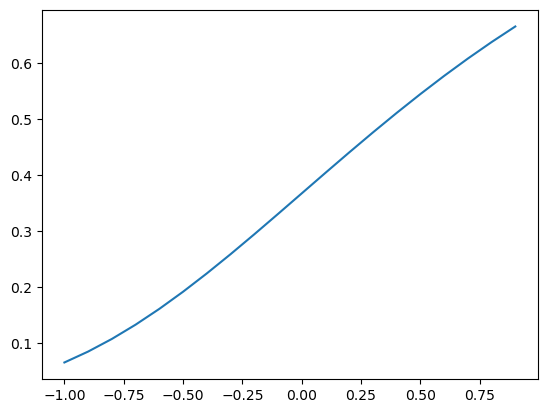

In [5]:
def gompertz_func3(x, a, b, c):
    return a * np.exp(-np.exp(-b * (x - c)))

x = np.arange(-1, 1, 0.1)

plt.plot(x, gompertz_func3(x, 1,1,0))

In [12]:
#par_bounds_de = [[0, 100], [np.min(years), np.max(years)], [0, np.max(values)], [0.1, 5]]

# for gompertz
par_bounds_de = [[0, 100*np.max(values)], [1e-12, 100], [0, 2*np.max(years)]]

diff_evol_values = generate_initial_parameters(par_bounds_de, gompertz_func3, years, values)
diff_evol_values

/tmp/ipykernel_14839/2455566507.py:2: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-np.exp(-b * (x - c)))


array([1.17018994e+05, 8.90089527e+01, 2.74175261e+03])

In [7]:
bounds = np.array(par_bounds_de).transpose()

init_guess = [np.max(values), 0.2, (np.min(years) + np.max(years)) / 2]

popt_r, pcov_r = curve_fit(gompertz_func3, years, values, p0=init_guess,
                                 maxfev=50000, bounds=bounds, verbose=1)

popt_r

`ftol` termination condition is satisfied.
Function evaluations 10, initial cost 1.3824e+07, final cost 3.6114e+05, first-order optimality 4.30e+02.


array([8.42747748e+03, 4.90950661e-01, 2.01520410e+03])

/media/Data/Projects/Measuring technology growth/growth-measures/curve_fitting.py:301: RuntimeWarning: overflow encountered in exp
  return asymptote * np.exp(-np.exp(-growth_rate * (x - time_shift)))


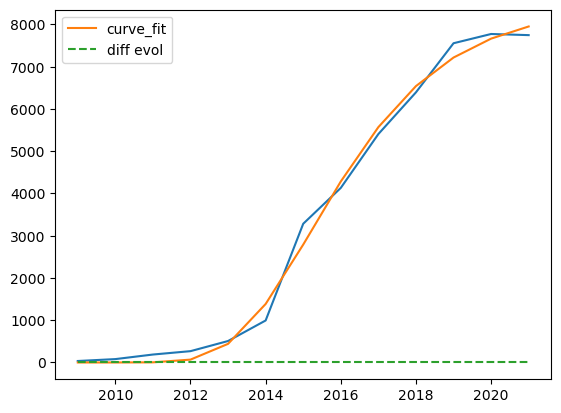

In [8]:
plt.plot(years, values)
plt.plot(years, gompertz_func(years, *popt_r), label='curve_fit')
plt.plot(years, gompertz_func(years, *diff_evol_values), '--', label='diff evol')
plt.legend()

### Notes:

Convergence of differential evolution to good fit depending strongly on the bounds that are set!

## Bass function

In [9]:
def bass_func2(x, a, b, c, d, e):
    return (c - e) * (1 - np.exp(-(a + b) * (x - d))) / (1 + (b / a) * np.exp(-(a + b) * (x - d))) + e

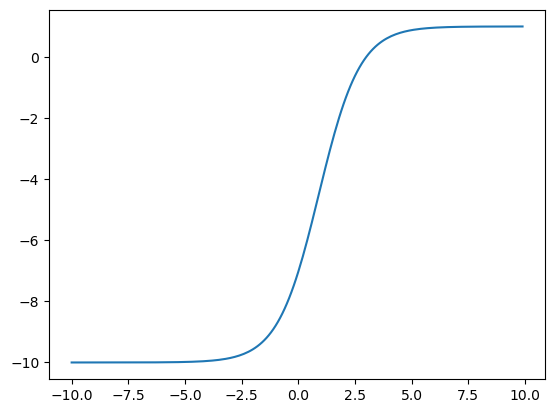

In [10]:
x = np.arange(-10, 10, 0.1)

plt.plot(x, bass_func2(x, 1, 0.1, 1, 3, 0))

In [11]:
# todo: understand what parameters do

par_bounds_de = [[0, 100*np.max(values)], [1e-12, 10], [0, 2*np.max(years), [0, 0], [0, 1]]]

diff_evol_values = generate_initial_parameters(par_bounds_de, bass_func2, years, values)
diff_evol_values

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

## Bertalanffy function

In [ ]:
def bertalanffy_func3(x, asymptote, growth_rate, time_shift, d):
    return asymptote * (1 - d * np.exp(-growth_rate * (x - time_shift))) ** 3

In [ ]:
def test_func(x, asymptote, growth_rate, time_shift, d):
    return asymptote * (1 - d * np.exp(-growth_rate * (x - time_shift)))

In [ ]:
x = np.arange(-10, 10, 0.1)

plt.plot(x, bertalanffy_func3(x, 1, 0.1, 0, 0.5))
plt.plot(x, test_func(x, 1, 0.1, 0, 0.5))

## Unified Richards function

In [ ]:
#def richards_func2(x, a, b, c, d, e):
#    return (c - e) * (1 - (1 / d) * np.exp(-a * (x - b))) ** d + e

In [ ]:
x = np.arange(-10, 10, 0.1)

plt.plot(x, richards_func2(x, 0.2, 0, 3, 1, 0))